# BÀI TẬP 5.5 - Gom cụm bài hát

---

**Họ và tên:** Nguyễn Quang Linh
**MSSV:** 038205003016

---

### 1.Load data, preprocessing, PCA

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

def get_fma_data(tracks_path, features_path, subset='small'):
    # 1. Load CSV (Multi-header)
    tracks = pd.read_csv(tracks_path, index_col=0, header=[0, 1])
    features = pd.read_csv(features_path, index_col=0, header=[0, 1, 2])
    # 2. Filter Subset
    subset_mask = tracks[('set', 'subset')] == subset
    small_tracks = tracks[subset_mask]

    # 3. Match Indices & Get Label
    x = features.loc[small_tracks.index]
    y = small_tracks[('track', 'genre_top')]

    # 4. Drop NaN
    if x.isnull().values.any():
        x = x.dropna()
        y = y.loc[x.index]

    return x, y


In [40]:
TRACKS_PATH = '../../data/Elearning05/fma_metadata/tracks.csv'
FEATURES_PATH = '../../data/Elearning05/fma_metadata/features.csv'

# Chạy hàm load
x_raw, y_true = get_fma_data(TRACKS_PATH, FEATURES_PATH)

print(f"Shape dữ liệu thô: {x_raw.shape}")
print(f"Các thể loại nhạc: {y_true.unique()}")

Shape dữ liệu thô: (8000, 518)
Các thể loại nhạc: ['Hip-Hop' 'Pop' 'Folk' 'Experimental' 'Rock' 'International' 'Electronic'
 'Instrumental']


In [18]:
# 1. Standard Scaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_raw)

# 2. PCA (Giữ 95% variance)
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(x_scaled)

print(f"Giảm chiều dữ liệu: {x_scaled.shape[1]} -> {x_pca.shape[1]}")

Giảm chiều dữ liệu: 518 -> 207


### 2. Chạy thử với Algo K-Mean

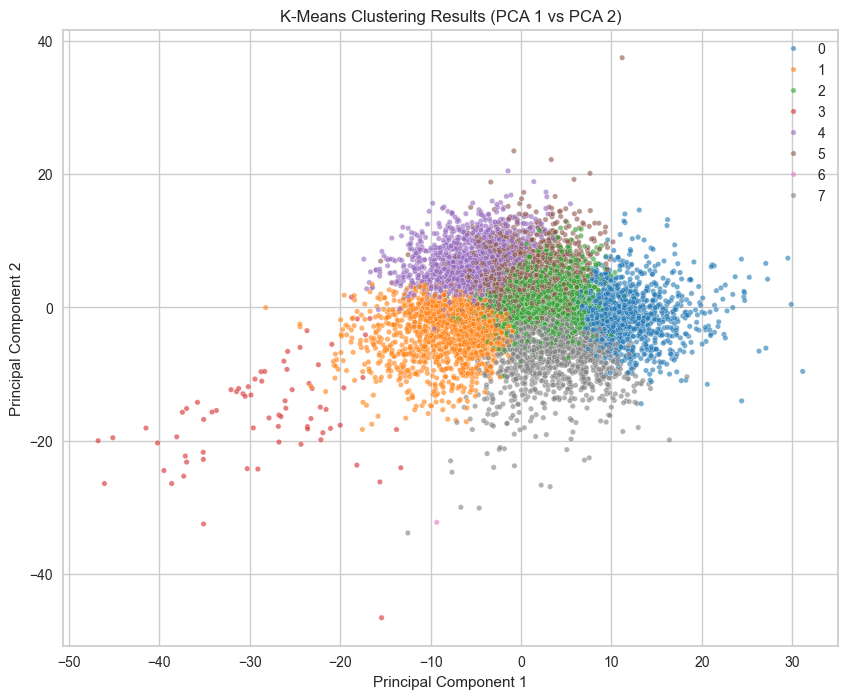

In [22]:
from sklearn.cluster import KMeans

# 1. Chạy K-Means (k=8)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
labels_kmean = kmeans.fit_predict(x_pca)

# 2. Plot kết quả dựa trên 2 thành phần PCA đầu tiên
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    hue=labels_kmean,
    palette='tab10',
    s=15,
    alpha=0.6,
    legend='full'
)
plt.title('K-Means Clustering Results (PCA 1 vs PCA 2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


### 3.Chạy thử với Algo Hierarchical Clustering (Agglomerative)

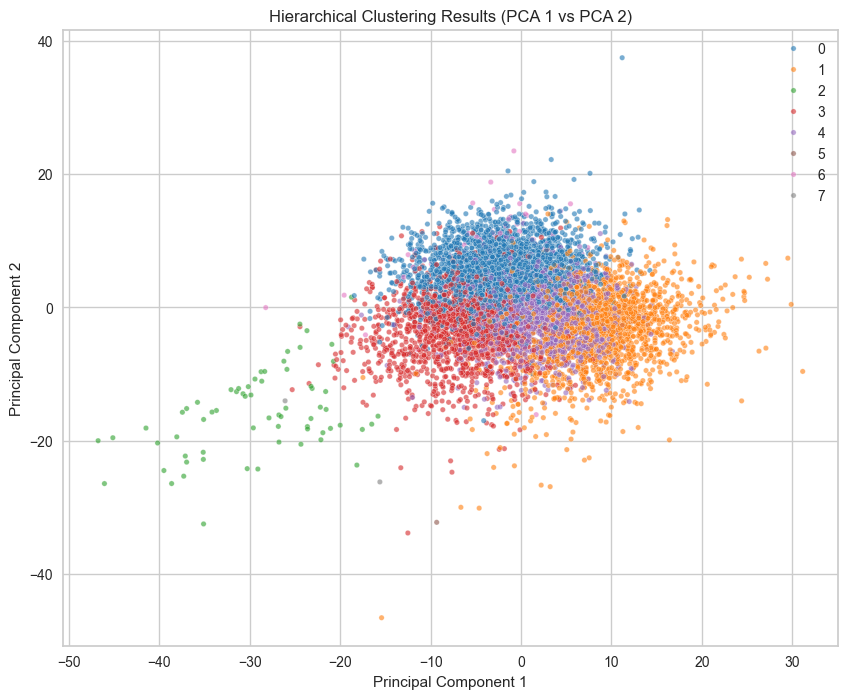

In [20]:
from sklearn.cluster import AgglomerativeClustering

# Run Agglomerative Clustering (k=8)
hc = AgglomerativeClustering(n_clusters=8)
labels_hc = hc.fit_predict(x_pca)

# Plot results (PCA 1 vs PCA 2)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    hue=labels_hc,
    palette='tab10',
    s=15,
    alpha=0.6,
    legend='full'
)
plt.title('Hierarchical Clustering Results (PCA 1 vs PCA 2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 4.Chạy thử với Algo Gaussian Mixture Models (GMM)

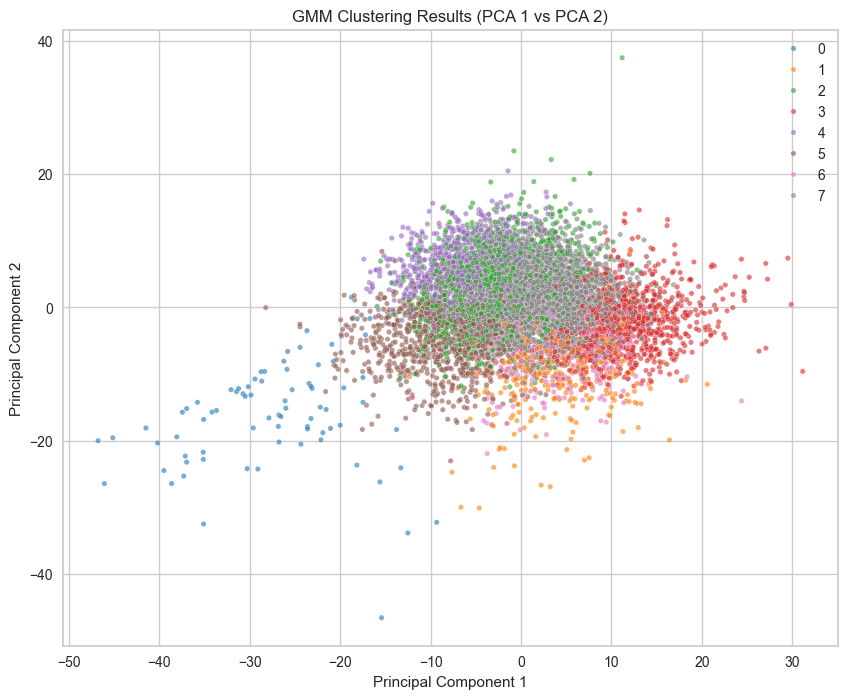

In [21]:
from sklearn.mixture import GaussianMixture

# Run Gaussian Mixture Models (k=8)
gmm = GaussianMixture(n_components=8, random_state=42)
labels_gmm = gmm.fit_predict(x_pca)

# Plot results (PCA 1 vs PCA 2)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    hue=labels_gmm,
    palette='tab10',
    s=15,
    alpha=0.6,
    legend='full'
)
plt.title('GMM Clustering Results (PCA 1 vs PCA 2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 5 (Visualize t-SNE) và 6 (So sánh/Kết luận)

 Đang tính điểm Silhouette và ARI...

=== BẢNG SO SÁNH KẾT QUẢ ===
      Algorithm  Silhouette       ARI
0       K-Means    0.021692  0.088277
1  Hierarchical    0.013521  0.085235
2           GMM    0.010370  0.040743

Đang chạy t-SNE 


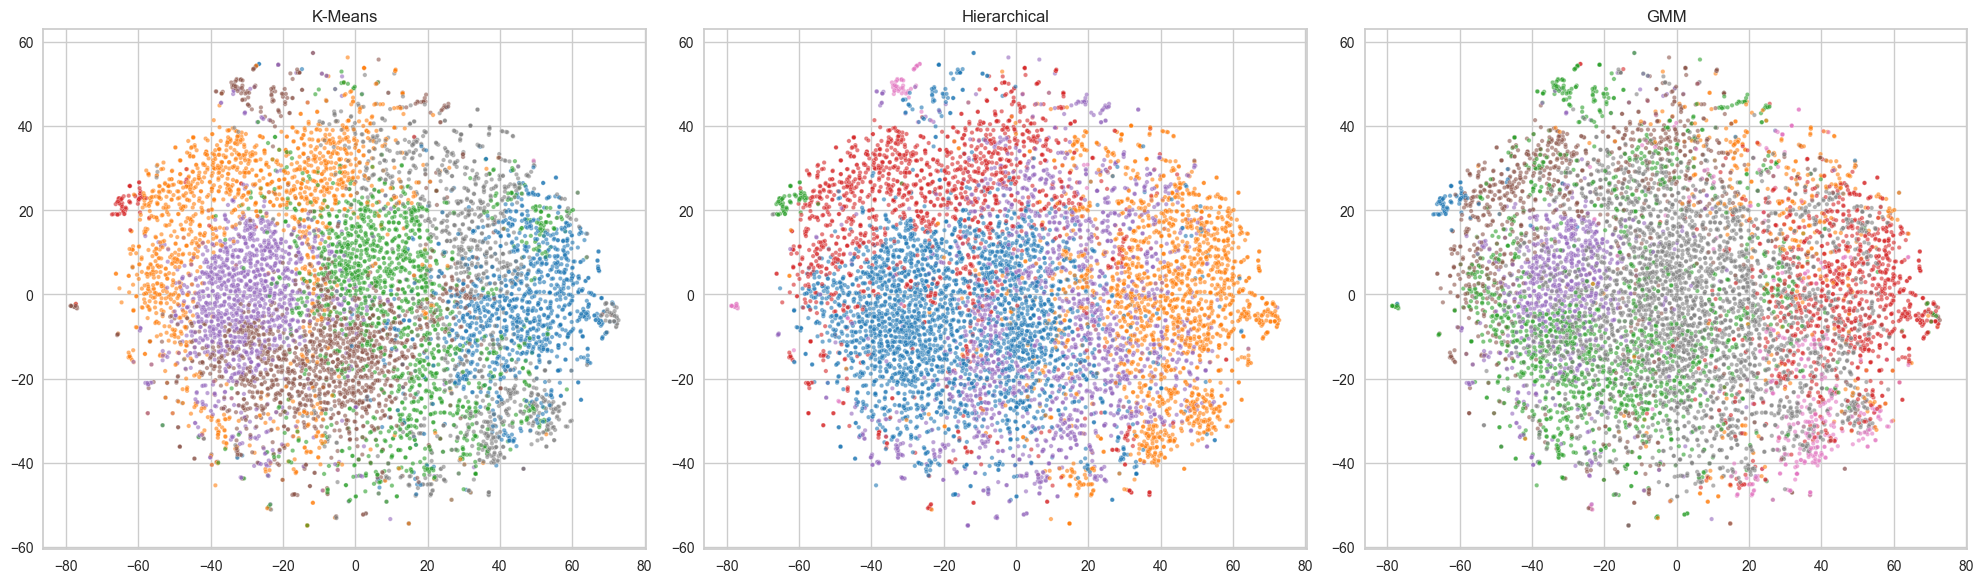

In [28]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score

# --- PHẦN 1: TÍNH ĐIỂM VÀ SO SÁNH ---
# Lưu ý: Đảm bảo tên biến khớp với các bước trước (labels_kmeans có 's')
models = {'K-Means': labels_kmean, 'Hierarchical': labels_hc, 'GMM': labels_gmm}
results = []

print(" Đang tính điểm Silhouette và ARI...")
for name, labels in models.items():
    sil = silhouette_score(x_pca, labels)
    ari = adjusted_rand_score(y_true, labels)
    results.append({'Algorithm': name, 'Silhouette': sil, 'ARI': ari})

# In bảng điểm
print("\n=== BẢNG SO SÁNH KẾT QUẢ ===")
df_results = pd.DataFrame(results)
print(df_results)

# --- PHẦN 2: TRỰC QUAN HÓA t-SNE ---
print("\nĐang chạy t-SNE ")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(x_pca)

# Vẽ 3 biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, labels) in zip(axes, models.items()):
    sns.scatterplot(
        x=X_embedded[:, 0], y=X_embedded[:, 1],
        hue=labels, palette='tab10', s=10, alpha=0.6,
        ax=ax, legend=False
    )
    ax.set_title(f'{name}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()